In [1]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define Paths
ZIP_PATH = '/content/drive/MyDrive/PlantProject/potato-disease(1).zip'
# This creates the specific directory name you want locally in Colab
EXTRACT_PATH = '/content/potato-disease(1)'

# 3. Clean Extraction Process
print(f"Creating directory: {EXTRACT_PATH}")

# Unzip the main container into your specific folder
# -o: overwrite, -q: quiet, -x: exclude macOS metadata
!unzip -o -q "{ZIP_PATH}" -d "{EXTRACT_PATH}" -x "__MACOSX/*" "**/._*"

# 4. Handle Nested Zip Files (If they exist)
# This looks inside your new directory for any internal .zip files to extract
for root, dirs, files in os.walk(EXTRACT_PATH):
    for file in files:
        if file.endswith(".zip"):
            inner_zip_path = os.path.join(root, file)
            # Extract internal zips directly into the main potato-disease(1) folder
            !unzip -o -q "{inner_zip_path}" -d "{EXTRACT_PATH}" -x "__MACOSX/*" "**/._*"
            # Remove the internal zip after extraction to keep it clean
            os.remove(inner_zip_path)
            print(f"✅ Extracted and cleaned internal zip: {file}")

# 5. Final Cleanup: Remove any empty nested 'potato-disease' folders
# This ensures you have 1 directory with 3 class folders inside
internal_folder = os.path.join(EXTRACT_PATH, 'potato-disease')
if os.path.exists(internal_folder):
    !rm -rf "{internal_folder}"

print(f"🚀 Success! Your data is ready at: {EXTRACT_PATH}")

Mounted at /content/drive
Creating directory: /content/potato-disease(1)
caution: excluded filename not matched:  **/._*
🚀 Success! Your data is ready at: /content/potato-disease(1)


In [2]:
# List the contents of your unzipped folder
!ls /content/data

ls: cannot access '/content/data': No such file or directory


In [3]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt


In [4]:

IMAGE_SIZE=256
BATCH_SIZE=32
CHANNELS=3
EPOCHS=50

In [5]:

# Load from your new single directory
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/potato-disease(1)",
    shuffle=True,
    image_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

#print(f"Confirmed Classes: {dataset.class_names}")

Found 5702 files belonging to 3 classes.


In [6]:
class_names=dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [7]:
len(dataset)

179

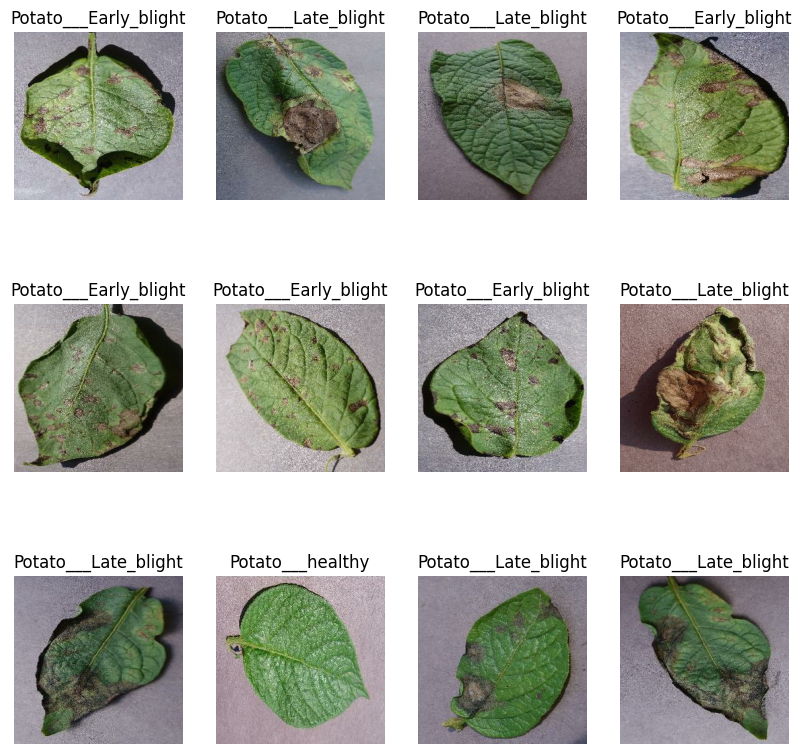

In [8]:
plt.figure(figsize=(10,10))
for image_batch, label_batch in dataset.take(1):
  for i in range(12):
    ax=plt.subplot(3,4,i+1)
    plt.imshow(image_batch[i].numpy().astype("uint8"))
    plt.title(class_names[label_batch[i]])
    plt.axis("off")

  #print(image_batch[0].shape)

In [10]:
train_size = 0.8
len(dataset)*train_size

143.20000000000002

In [11]:
train_ds= dataset.take(143)
len(train_ds)

143

In [12]:
test_ds = dataset.skip(143)
len(test_ds)

36

In [13]:
val_size=0.1
len(dataset)*val_size

17.900000000000002

In [14]:
val_ds = test_ds.take(17)
len(val_ds)

17

In [15]:
test_ds = test_ds.skip(17)
len(test_ds)

19

In [16]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)

    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [17]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [19]:
len(dataset)

179

In [20]:
len(val_ds)

17

In [21]:
len(test_ds)

19

In [22]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [23]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE,IMAGE_SIZE),
    layers.Rescaling(1.0/255)
])

In [24]:
import numpy as np

# 1. Take one batch of images and labels from your dataset
for images, labels in dataset.take(1):
    # 2. Apply the resize_and_rescale layer to the batch
    processed_images = resize_and_rescale(images)

    # 3. Check the new dimensions (Shape)
    print(f"Original Shape: {images.shape}")
    print(f"Processed Shape: {processed_images.shape}")

    # 4. Check the pixel value range (Min and Max)
    # Original should be 0 to 255; Processed should be 0.0 to 1.0
    print(f"Original Min/Max: {np.min(images)}, {np.max(images)}")
    print(f"Processed Min/Max: {np.min(processed_images)}, {np.max(processed_images)}")

Original Shape: (32, 256, 256, 3)
Processed Shape: (32, 256, 256, 3)
Original Min/Max: 0.0, 255.0
Processed Min/Max: 0.0, 1.0


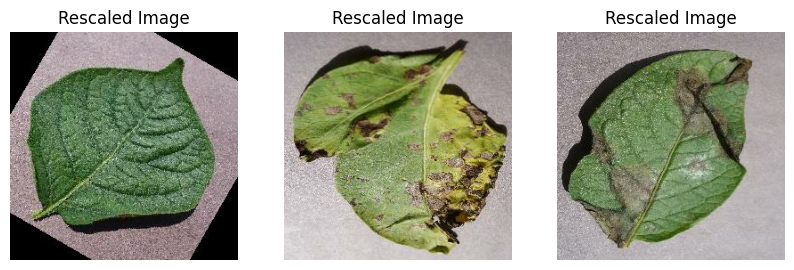

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, _ in dataset.take(1):
    processed_images = resize_and_rescale(images)
    for i in range(3):
        ax = plt.subplot(1, 3, i + 1)
        # We use .numpy() to convert the tensor for plotting
        plt.imshow(processed_images[i].numpy())
        plt.title("Rescaled Image")
        plt.axis("off")

In [26]:
data_augmentation=tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [27]:
model = models.Sequential([
    layers.InputLayer(input_shape=(256, 256, 3)),
    resize_and_rescale,
    data_augmentation,

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(), # Stabilizes learning
    layers.MaxPooling2D((2, 2)),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'), # Increased filter count
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # Global Average Pooling instead of Flatten
    layers.GlobalAveragePooling2D(),

    # Fully Connected Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,139 (1012.26 KB)

 Trainable params: 258,435 (1009.51 KB)

 Non-trainable params: 704 (2.75 KB)

In [29]:

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
     train_ds,
     epochs=EPOCHS,
     batch_size=BATCH_SIZE,
     verbose=1,
     validation_data=val_ds
)

Epoch 1/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1178s 8s/step - accuracy: 0.8672 - loss: 0.3410 - val_accuracy: 0.3750 - val_loss: 5.6402
Epoch 2/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1212s 8s/step - accuracy: 0.9638 - loss: 0.1020 - val_accuracy: 0.3750 - val_loss: 6.5846
Epoch 3/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1145s 8s/step - accuracy: 0.9632 - loss: 0.1113 - val_accuracy: 0.4908 - val_loss: 3.5239
Epoch 4/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1135s 8s/step - accuracy: 0.9760 - loss: 0.0676 - val_accuracy: 0.6048 - val_loss: 2.6372
Epoch 5/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1162s 8s/step - accuracy: 0.9773 - loss: 0.0624 - val_accuracy: 0.8989 - val_loss: 0.3611
Epoch 6/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1127s 8s/step - accuracy: 0.9777 - loss: 0.0626 - val_accuracy: 0.9173 - val_loss: 0.3133
Epoch 7/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1126s 8s/step - accuracy: 0.9784 - loss: 0.0511 - val_accuracy: 0.6967 - val_loss: 1.7723
Epoch 8/50
143/143 ━━━━━━━━━━━━━━━━━━━━ 1123s 8s/step - accuracy: 0.9845 - loss: 0.0461 - 

In [30]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the path in your project folder
# Replace 'PlantProject' with your actual folder name
save_path = '/content/drive/MyDrive/PlantProject/potato_model.h5'

model.save(save_path)
print(f"✅ Model saved successfully to: {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model saved successfully to: /content/drive/MyDrive/PlantProject/potato_model.h5
